# 🏥 MediGemma — Multimodal Pipeline
**`notebooks/02_test_multimodal.ipynb`**

This notebook tests and demonstrates the full multimodal RAG pipeline:

| Step | Module | What it does |
|------|--------|--------------|
| 1 | `knowledge_base.py` | Ingest & chunk medical text documents |
| 2 | `image_processor.py` | Load, validate & preprocess medical images |
| 3 | `visual_embedder.py` | Encode images + text into shared embedding space |
| 4 | `vector_store.py` | Store & retrieve via ChromaDB |
| 5 | Safety checks | Risk classification + disclaimer injection |

> ⚠️ **Disclaimer:** MediGemma provides health guidance only. Always consult a qualified healthcare provider.

## 0 · Environment Setup

In [2]:
# Install required packages (run once)
# !pip install -e ..          # editable install — makes all imports work
# !pip install transformers torch torchvision
# !pip install langchain-chroma chromadb
# !pip install Pillow numpy
%pip install pytesseract matplotlib    # optional — enables OCR on lab reports
print('✅ Dependencies assumed installed')

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies assumed installed



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [ ]:
import sys
import logging
from pathlib import Path

# Ensure project root is on sys.path (only needed if NOT using pip install -e .)
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('medigemma.notebook')

print(f'📁 Project root: {PROJECT_ROOT}')

In [2]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 11.0 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 10.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.2 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.1 MB/s  0:00:00
Using cac


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Standard imports
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── MediGemma imports ──────────────────────────────────────────────────────
from config.settings import (
    CHROMA_PERSIST_DIR,
    CHROMA_COLLECTION_NAME,
    EMBEDDING_MODEL,
)
from src.rag.knowledge_base    import MedicalKnowledgeBase
from src.rag.vector_store      import MedicalVectorStore, transform_kb_chunks_to_docs
from src.preprocessing.image_processor import MedicalImageProcessor, ProcessedImage
from src.preprocessing.visual_embedder import VisualEmbedder

print('✅ All imports successful')

c:\santosh\MediGemma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful


---
## 1 · Text Processing — Knowledge Base Ingestion

In [ ]:
# ── Initialise knowledge base ──────────────────────────────────────────────
kb = MedicalKnowledgeBase(output_dir='../data')

# Point to your documents folder — adjust glob pattern as needed
KB_DIR = PROJECT_ROOT / 'data' / 'knowledge_base'

doc_files = (
    list(KB_DIR.rglob('*.txt')) +
    list(KB_DIR.rglob('*.md'))
)

if not doc_files:
    # ── Synthetic demo documents when no real files are present ──────────
    print('⚠️  No documents found in data/knowledge_base/ — using synthetic demo data')

    SYNTHETIC_DOCS = [
        {
            'filename': 'who_hypertension.txt',
            'content': (
                'Title: Hypertension Management Guidelines\n'
                'Source: World Health Organization\n\n'
                'Hypertension (high blood pressure) is a major risk factor for '
                'cardiovascular disease and stroke (cerebrovascular accident). '
                'Blood pressure consistently above 140/90 mmHg is classified as hypertension. '
                'First-line treatment includes lifestyle modifications: reduced sodium intake, '
                'regular physical activity, weight management, and smoking cessation. '
                'Pharmacological treatment: ACE inhibitors, calcium channel blockers, '
                'or thiazide diuretics are recommended as first-line agents.\n\n'
                'Emergency hypertension (>180/120 with organ damage) requires immediate '
                'hospital admission. Call emergency services immediately for hypertensive crisis.'
            ),
        },
        {
            'filename': 'cdc_chest_pain_protocol.txt',
            'content': (
                'Title: Chest Pain Triage Protocol\n'
                'Source: Centers for Disease Control\n\n'
                'Chest pain can indicate a heart attack (myocardial infarction). '
                'Call 911 immediately if chest pain is: crushing, radiating to the arm or jaw, '
                'accompanied by shortness of breath, sweating, or nausea. '
                'Do not drive yourself to the hospital. '
                'Aspirin 325 mg may be given if not allergic and no contraindications. '
                'For mild, positional chest pain in young patients consider musculoskeletal causes.'
            ),
        },
        {
            'filename': 'nhs_skin_lesions.txt',
            'content': (
                'Title: Skin Lesion Assessment\n'
                'Source: National Health Service\n\n'
                'Use the ABCDE rule for skin lesion assessment:\n'
                'A — Asymmetry: one half unlike the other\n'
                'B — Border: irregular or poorly defined border\n'
                'C — Colour: varied from one area to another\n'
                'D — Diameter: larger than 6 mm\n'
                'E — Evolving: changing in size, shape, or colour\n\n'
                'Lesions meeting 2+ ABCDE criteria should be referred to a dermatologist urgently. '
                'Common benign lesions include seborrhoeic keratosis and dermatofibromas.'
            ),
        },
    ]

    # Write synthetic docs to temp dir for loading
    import tempfile, os
    tmp_dir = Path(tempfile.mkdtemp())
    doc_files = []
    for d in SYNTHETIC_DOCS:
        fp = tmp_dir / d['filename']
        fp.write_text(d['content'], encoding='utf-8')
        doc_files.append(str(fp))
    print(f'✅ Created {len(doc_files)} synthetic demo documents')
else:
    doc_files = [str(f) for f in doc_files]
    print(f'📂 Found {len(doc_files)} documents in {KB_DIR}')

In [ ]:
# ── Load and chunk ─────────────────────────────────────────────────────────
kb.load_documents(doc_files)
chunks = kb.generate_chunks()

print(f'\n📊 Knowledge base summary:')
print(f'   Documents : {len(kb.documents)}')
print(f'   Chunks    : {len(chunks)}')

if chunks:
    print(f'\n📄 Sample chunk (first 250 chars):')
    print(f'   {chunks[0].text[:250]}...')
    print(f'   metadata: {chunks[0].metadata}')

In [ ]:
# ── Visualise domain + risk distribution ──────────────────────────────────
from collections import Counter

domains     = [c.metadata.get('domain',     'unknown') for c in chunks]
risk_levels = [c.metadata.get('risk_level', 'unknown') for c in chunks]
priorities  = [c.metadata.get('priority',   0)         for c in chunks]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Domain distribution
domain_counts = Counter(domains)
axes[0].bar(domain_counts.keys(), domain_counts.values(), color='steelblue')
axes[0].set_title('Chunks by Domain')
axes[0].tick_params(axis='x', rotation=30)

# Risk level distribution
risk_counts  = Counter(risk_levels)
colors_risk  = {'emergency': 'red', 'high': 'orange', 'medium': 'gold', 'low': 'green', 'unknown': 'grey'}
axes[1].bar(
    risk_counts.keys(),
    risk_counts.values(),
    color=[colors_risk.get(r, 'grey') for r in risk_counts.keys()]
)
axes[1].set_title('Chunks by Risk Level')

# Priority histogram
axes[2].hist(priorities, bins=range(1, 12), color='mediumpurple', edgecolor='black', align='left')
axes[2].set_title('Clinical Priority Distribution')
axes[2].set_xlabel('Priority (higher = more urgent)')

plt.tight_layout()
plt.suptitle('📊 Knowledge Base Statistics', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 2 · Image Processing — Medical Image Preprocessing

In [4]:
from src.preprocessing.image_processor import MedicalImageProcessor, MODALITY_SIZES

img_processor = MedicalImageProcessor(
    enhance_contrast=True,
    run_ocr=False,      # set True if pytesseract is installed
)
print('✅ MedicalImageProcessor initialised')

✅ MedicalImageProcessor initialised


In [5]:
# ── Create synthetic test images for each modality ────────────────────────
from PIL import ImageDraw, ImageFont
import random

def make_synthetic_image(modality: str, size=(256, 256)) -> Image.Image:
    """Generate a visually distinct synthetic image per modality."""
    img = Image.new('RGB', size, color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    if modality == 'xray':
        # Greyscale gradient with rib-like lines
        for i in range(0, size[1], 20):
            shade = int(40 + (i / size[1]) * 180)
            draw.line([(0, i), (size[0], i)], fill=(shade, shade, shade), width=3)
        draw.ellipse([80, 60, 176, 196], fill=(90, 90, 90))

    elif modality == 'skin':
        # Skin-toned background with lesion
        img.paste(Image.new('RGB', size, (210, 170, 130)))
        draw = ImageDraw.Draw(img)
        draw.ellipse([90, 90, 166, 166], fill=(80, 40, 40))   # dark lesion
        draw.ellipse([100, 100, 145, 145], fill=(60, 20, 20)) # darker centre

    elif modality == 'wound':
        img.paste(Image.new('RGB', size, (220, 180, 160)))
        draw = ImageDraw.Draw(img)
        draw.polygon([(100, 110), (156, 108), (160, 148), (98, 150)],
                     fill=(180, 30, 30))

    elif modality == 'lab_report':
        draw.rectangle([10, 10, size[0]-10, size[1]-10], outline=(0, 0, 0), width=2)
        lines = [
            'LAB REPORT', 'Patient: J. Doe', 'Date: 2024-01-15',
            'Glucose: 6.2 mmol/L', 'HbA1c: 7.1%', 'BP: 138/88 mmHg',
        ]
        for j, line in enumerate(lines):
            draw.text((20, 20 + j * 30), line, fill=(0, 0, 0))

    return img

MODALITIES = ['xray', 'skin', 'wound', 'lab_report']
synthetic_images = {m: make_synthetic_image(m) for m in MODALITIES}
print(f'✅ Created synthetic images for: {MODALITIES}')

✅ Created synthetic images for: ['xray', 'skin', 'wound', 'lab_report']


2026-06-07 21:51:24,440 - INFO - ✅ Processed image | modality=xray | size=(512, 512) | ocr_chars=0
2026-06-07 21:51:24,479 - INFO - ✅ Processed image | modality=skin | size=(384, 384) | ocr_chars=0
2026-06-07 21:51:24,552 - INFO - ✅ Processed image | modality=wound | size=(384, 384) | ocr_chars=0
2026-06-07 21:51:24,630 - INFO - ✅ Processed image | modality=lab_report | size=(768, 1024) | ocr_chars=0


[xray        ] size=(512, 512) | risk=low       | domain=respiratory
[skin        ] size=(384, 384) | risk=low       | domain=dermatology
[wound       ] size=(384, 384) | risk=low       | domain=general_medicine
[lab_report  ] size=(768, 1024) | risk=low       | domain=general_medicine


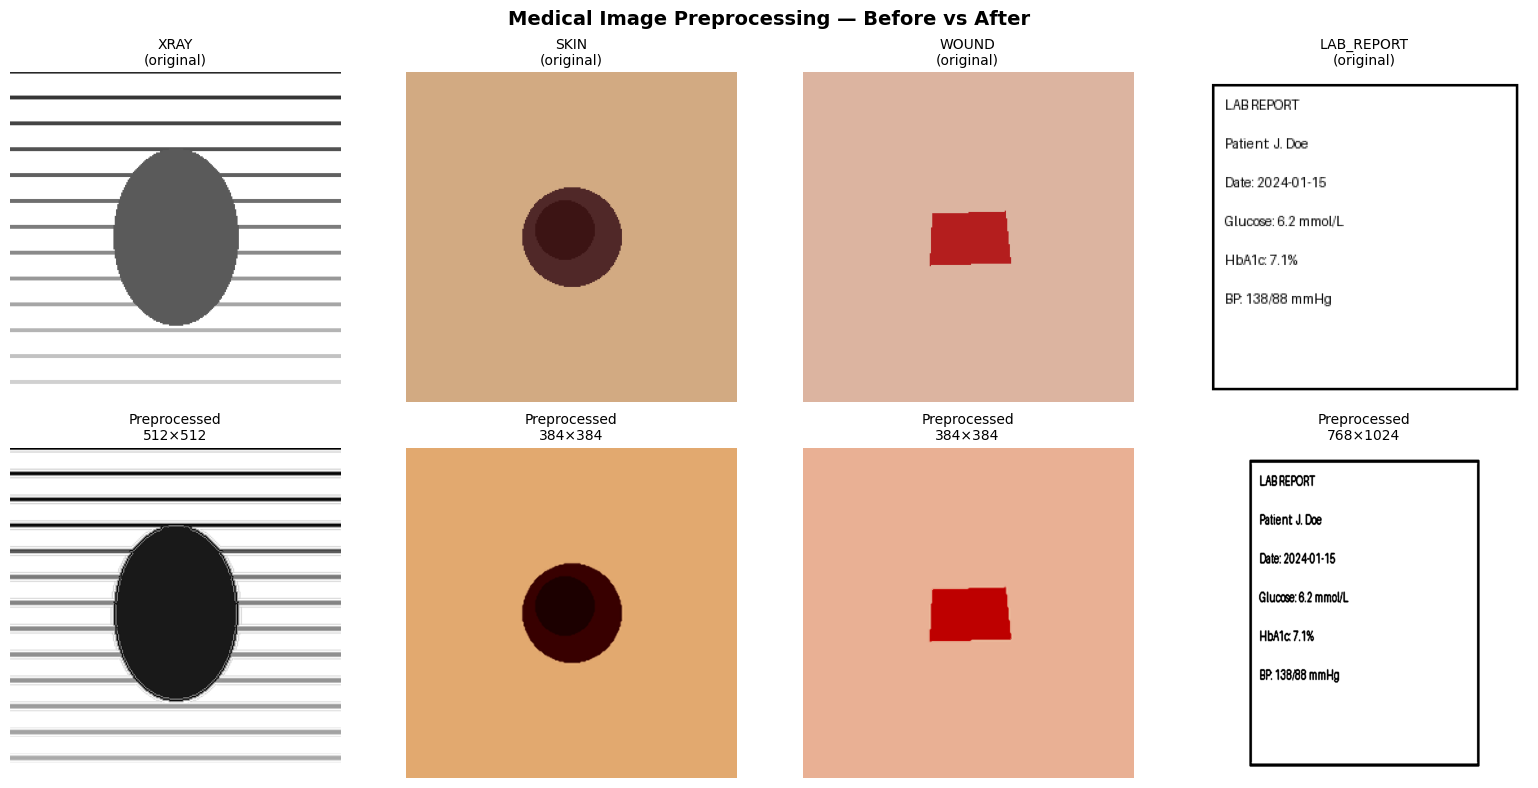

In [6]:
# ── Process each modality and display before/after ────────────────────────
processed_images: dict[str, ProcessedImage] = {}

fig, axes = plt.subplots(2, len(MODALITIES), figsize=(16, 8))
fig.suptitle('Medical Image Preprocessing — Before vs After', fontsize=14, fontweight='bold')

for col, modality in enumerate(MODALITIES):
    raw_img = synthetic_images[modality]
    result  = img_processor.process(raw_img, modality=modality)
    processed_images[modality] = result

    # Before
    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(f'{modality.upper()}\n(original)', fontsize=10)
    axes[0, col].axis('off')

    # After
    axes[1, col].imshow(result.image)
    axes[1, col].set_title(
        f'Preprocessed\n{result.image_array.shape[1]}×{result.image_array.shape[0]}',
        fontsize=10
    )
    axes[1, col].axis('off')

    print(f'[{modality:12s}] size={result.image.size} | '
          f'risk={result.metadata["risk_level"]:9s} | '
          f'domain={result.metadata["domain"]}')

plt.tight_layout()
plt.show()

2026-06-07 21:55:53,257 - INFO - ✅ Processed image | modality=xray | size=(512, 512) | ocr_chars=0


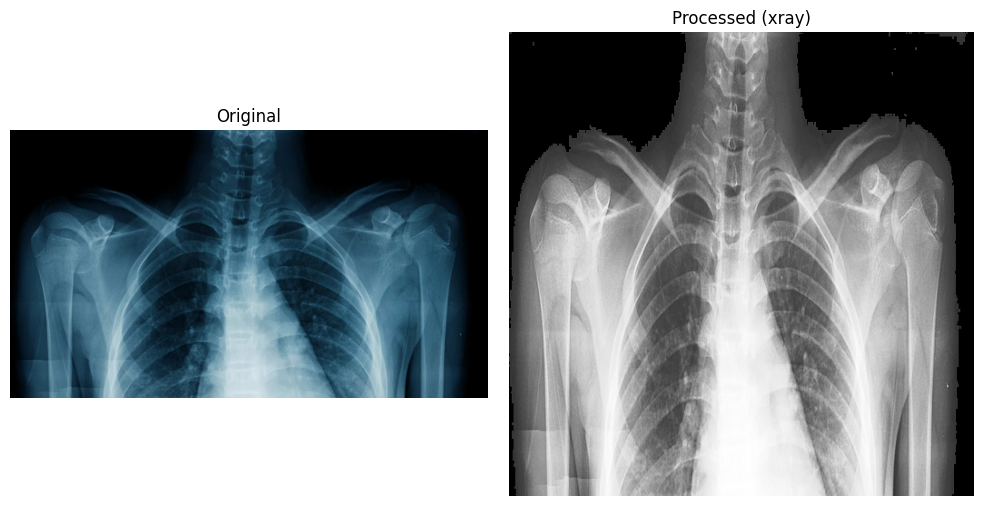

Metadata: {'source': 'x-ray.webp', 'modality': 'xray', 'image_width': 512, 'image_height': 512, 'has_ocr_text': False, 'ocr_text_length': 0, 'risk_level': 'low', 'domain': 'respiratory', 'input_type': 'image'}


In [8]:
from pathlib import Path
# ── Test with a real image file (optional) ────────────────────────────────
REAL_IMAGE_PATH = 'x-ray.webp'   # change to a real path

if Path(REAL_IMAGE_PATH).exists():
    from src.preprocessing.image_processor import load_and_process_image
    real_result = load_and_process_image(REAL_IMAGE_PATH, run_ocr=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(REAL_IMAGE_PATH))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(real_result.image)
    axes[1].set_title(f'Processed ({real_result.modality})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Metadata: {real_result.metadata}')
else:
    print(f'ℹ️  No real image found at {REAL_IMAGE_PATH} — skipping real-image test')

---
## 3 · Visual Embedding — Text + Image → Shared Vector Space

In [9]:
from src.preprocessing.visual_embedder import VisualEmbedder

embedder = VisualEmbedder()   # loads CLIP if available, falls back to BGE
print(f'✅ VisualEmbedder ready | dim={embedder.embedding_dim} | CLIP={embedder._clip_available}')

2026-06-07 21:57:30,147 - INFO - 🔧 Loading CLIP model: openai/clip-vit-base-patch32
2026-06-07 21:57:31,270 - INFO - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-07 21:57:31,579 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-06-07 21:57:31,988 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
c:\santosh\MediGemma\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ranas\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degrad

✅ VisualEmbedder ready | dim=512 | CLIP=True


In [ ]:
# ── Embed text queries ─────────────────────────────────────────────────────
TEXT_QUERIES = [
    'patient has chest pain and difficulty breathing',
    'skin lesion with irregular borders and colour variation',
    'open wound with signs of infection',
    'lab report shows elevated glucose and HbA1c',
    'hypertension management guidelines',
]

text_vecs = {q: embedder.embed_text(q) for q in TEXT_QUERIES}
print(f'✅ Embedded {len(text_vecs)} text queries | shape: {list(text_vecs.values())[0].shape}')

In [ ]:
# ── Embed images ───────────────────────────────────────────────────────────
image_vecs = {}
for modality, proc_img in processed_images.items():
    vec = embedder.embed_image(proc_img.image)
    image_vecs[modality] = vec
    print(f'  [{modality:12s}] embedding shape={vec.shape} | norm={np.linalg.norm(vec):.4f}')

print(f'\n✅ Embedded {len(image_vecs)} images')

In [ ]:
# ── Fused multimodal embeddings ────────────────────────────────────────────
MULTIMODAL_PAIRS = [
    ('chest pain radiating to left arm', 'xray',       0.5, 0.5),
    ('irregular dark skin lesion',       'skin',       0.6, 0.4),
    ('deep wound with redness',          'wound',      0.6, 0.4),
    ('patient glucose 11.2 mmol/L',     'lab_report', 0.7, 0.3),
]

fused_vecs = {}
print('Fused (text + image) embedding norms:')
for text, modality, tw, iw in MULTIMODAL_PAIRS:
    fused = embedder.embed_multimodal(
        text=text,
        image=processed_images[modality].image,
        text_weight=tw,
        image_weight=iw,
    )
    key = f'{modality}+text'
    fused_vecs[key] = fused
    print(f'  [{key:20s}] shape={fused.shape} | norm={np.linalg.norm(fused):.4f}')

print(f'\n✅ Created {len(fused_vecs)} fused embeddings')

In [ ]:
# ── Cosine similarity heatmap: text queries × image modalities ────────────
query_labels    = [q[:35] + '...' if len(q) > 35 else q for q in TEXT_QUERIES]
modality_labels = list(image_vecs.keys())

sim_matrix = np.zeros((len(TEXT_QUERIES), len(modality_labels)))
for i, query in enumerate(TEXT_QUERIES):
    for j, modality in enumerate(modality_labels):
        sim_matrix[i, j] = embedder.similarity(
            text_vecs[query], image_vecs[modality]
        )

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=1.0)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(len(modality_labels)))
ax.set_xticklabels([m.upper() for m in modality_labels], fontsize=11)
ax.set_yticks(range(len(query_labels)))
ax.set_yticklabels(query_labels, fontsize=9)
ax.set_title('Text Query ↔ Image Modality Cosine Similarity', fontsize=13, fontweight='bold')
for i in range(len(TEXT_QUERIES)):
    for j in range(len(modality_labels)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black')
plt.tight_layout()
plt.show()

In [ ]:
# ── Zero-shot image classification against medical labels ─────────────────
MEDICAL_LABELS = [
    'chest X-ray showing pneumonia',
    'melanoma skin lesion',
    'infected wound requiring treatment',
    'normal blood test results',
    'hypertensive crisis',
    'diabetic foot ulcer',
    'fractured bone',
]

print('🔍 Zero-shot image classification (CLIP):' if embedder._clip_available
      else '🔍 Zero-shot classification (text similarity fallback):')
print('─' * 60)

for modality, proc_img in processed_images.items():
    ranked = embedder.rank_texts_by_image(
        image=proc_img.image,
        texts=MEDICAL_LABELS,
        top_k=3,
    )
    print(f'\n  [{modality.upper()}]')
    for label, score in ranked:
        bar = '█' * int(score * 20 + 10)
        print(f'    {score:.3f} {bar} {label}')

---
## 4 · Vector Store — Index & Retrieve

In [ ]:
# ── Initialise vector store ────────────────────────────────────────────────
# Use a separate collection for this test to avoid polluting production data
vs = MedicalVectorStore(
    persist_dir='../data/chroma_multimodal_test',
    collection_name='multimodal_test',
)
print(f'✅ VectorStore ready: {vs.get_collection_stats()}')

In [ ]:
# ── Index text chunks ──────────────────────────────────────────────────────
doc_dicts = transform_kb_chunks_to_docs([c.__dict__ if hasattr(c, '__dict__') else c
                                          for c in chunks])
# transform_kb_chunks_to_docs expects list of dicts with 'chunk_id','text','metadata'
# MedicalChunk dataclass → convert properly
from dataclasses import asdict
doc_dicts = transform_kb_chunks_to_docs(
    [{'chunk_id': c.chunk_id, 'text': c.text, 'metadata': c.metadata} for c in chunks]
)

added = vs.add_documents(doc_dicts)
print(f'✅ Indexed {added} text chunks')
print(f'   Collection stats: {vs.get_collection_stats()}')

In [ ]:
# ── Index image-derived documents ─────────────────────────────────────────
# For each processed image, create a pseudo-document:
#   • content = modality description + OCR text (if any)
#   • metadata mirrors MedicalChunk schema

IMAGE_DESCRIPTIONS = {
    'xray':       'Chest X-ray showing lung fields. Possible infiltrate in right lower lobe. '
                  'Cardiac silhouette within normal limits.',
    'skin':       'Skin lesion with irregular asymmetric borders and colour variation '
                  '(dark brown and black). Diameter approximately 8 mm. Refer dermatology.',
    'wound':      'Open wound on lower extremity with surrounding erythema and mild swelling. '
                  'No deep structure involvement visible. Clean and dress wound.',
    'lab_report': 'Blood test results: Glucose 11.2 mmol/L (high), HbA1c 7.1% (above target), '
                  'BP 138/88 mmHg. Consistent with poorly controlled type-2 diabetes mellitus.',
}

image_docs = []
for modality, proc_img in processed_images.items():
    description = IMAGE_DESCRIPTIONS.get(modality, f'{modality} image')
    ocr_suffix  = f' OCR: {proc_img.extracted_text}' if proc_img.extracted_text else ''

    image_docs.append({
        'id':       f'img_{modality}_001',
        'content':  description + ocr_suffix,
        'metadata': {
            **proc_img.metadata,
            'source':     f'image_{modality}',
            'input_type': 'image',
            'doc_title':  f'{modality.replace("_", " ").title()} Image',
            'priority':   8,
        },
    })

added_imgs = vs.add_documents(image_docs)
print(f'✅ Indexed {added_imgs} image documents')
print(f'   Total collection size: {vs.get_collection_stats()["count"]}')

In [ ]:
# ── Retrieve — text query ──────────────────────────────────────────────────
TEXT_QUERY = 'chest pain shortness of breath possible heart attack'

results_text = vs.similarity_search(TEXT_QUERY, k=4)

print(f'🔍 Query: "{TEXT_QUERY}"')
print(f'   Retrieved {len(results_text)} documents:\n')
for i, doc in enumerate(results_text, 1):
    print(f'  [{i}] {doc.metadata.get("doc_title", "—")} '
          f'| domain={doc.metadata.get("domain","—")} '
          f'| risk={doc.metadata.get("risk_level","—")} '
          f'| input={doc.metadata.get("input_type","text")}')
    print(f'      "{doc.page_content[:120]}..."\n')

In [ ]:
# ── Retrieve — image query (via description) ───────────────────────────────
IMAGE_QUERY = 'dark irregular skin lesion possible melanoma'

results_img = vs.similarity_search(
    IMAGE_QUERY,
    k=4,
    where={'domain': 'dermatology'},   # filter to skin domain
)

print(f'🔍 Query: "{IMAGE_QUERY}" [filtered: domain=dermatology]')
print(f'   Retrieved {len(results_img)} documents:\n')
for i, doc in enumerate(results_img, 1):
    print(f'  [{i}] {doc.metadata.get("doc_title", "—")} '
          f'| input={doc.metadata.get("input_type","text")}')
    print(f'      "{doc.page_content[:120]}..."\n')

In [ ]:
# ── Retrieve — fused multimodal query ─────────────────────────────────────
# Build a combined query string from text + image description
FUSED_TEXT  = 'open wound with redness and swelling possible infection'
FUSED_IMAGE = processed_images['wound'].image

# If CLIP available: get fused vector and use direct ChromaDB query
# Otherwise: combine text query with image description
if embedder._clip_available:
    fused_query_vec = embedder.embed_multimodal(FUSED_TEXT, FUSED_IMAGE)
    # ChromaDB raw query with embedding
    raw_collection  = vs.client.get_collection(vs.collection_name)
    raw_results     = raw_collection.query(
        query_embeddings=[fused_query_vec.tolist()],
        n_results=4,
    )
    docs_texts = raw_results['documents'][0]
    docs_metas = raw_results['metadatas'][0]
    print(f'🔍 Fused query (CLIP) — retrieved {len(docs_texts)} docs:')
    for i, (txt, meta) in enumerate(zip(docs_texts, docs_metas), 1):
        print(f'  [{i}] {meta.get("doc_title","—")} | risk={meta.get("risk_level","—")}')
        print(f'      "{txt[:100]}..."\n')
else:
    # Fallback: concatenate text description
    combined_query = f'{FUSED_TEXT}. Image shows: {IMAGE_DESCRIPTIONS["wound"]}'
    results_fused  = vs.hybrid_search(combined_query, k=4)
    print(f'🔍 Fused query (text-only fallback) — retrieved {len(results_fused)} docs:')
    for i, doc in enumerate(results_fused, 1):
        print(f'  [{i}] {doc.metadata.get("doc_title","—")} | risk={doc.metadata.get("risk_level","—")}')
        print(f'      "{doc.page_content[:100]}..."\n')

---
## 5 · Safety Checks — Risk Classification + Disclaimer Injection

In [ ]:
# ── Runtime safety layer (from knowledge_base.py) ─────────────────────────
# MedicalKnowledgeBase.apply_safety_layer() prepends the appropriate
# disclaimer to retrieved content based on its risk_level metadata.

print('🛡️  Safety Layer Test')
print('=' * 60)

TEST_CASES = [
    {
        'content':  'Administer aspirin 325 mg immediately for suspected myocardial infarction.',
        'metadata': {'risk_level': 'emergency', 'disclaimer_tag': 'emergency'},
    },
    {
        'content':  'Refer for urgent biopsy if ABCDE criteria met for skin lesion.',
        'metadata': {'risk_level': 'high', 'disclaimer_tag': 'high'},
    },
    {
        'content':  'Monitor blood pressure weekly and reduce sodium intake.',
        'metadata': {'risk_level': 'low', 'disclaimer_tag': 'low'},
    },
]

for case in TEST_CASES:
    safe_content = kb.apply_safety_layer(case['content'], case['metadata'])
    risk = case['metadata']['risk_level'].upper()
    color_map = {'EMERGENCY': '🚨', 'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}
    icon = color_map.get(risk, '⚪')
    print(f'\n{icon} Risk: {risk}')
    print('-' * 50)
    print(safe_content[:300])
    print()

In [ ]:
# ── Image-level safety check ───────────────────────────────────────────────
# Assess risk from image metadata (set during preprocessing)

print('🛡️  Image Safety Assessment')
print('=' * 60)

RISK_COLORS = {'emergency': '🚨', 'high': '🔴', 'medium': '🟡', 'low': '🟢'}

for modality, proc_img in processed_images.items():
    risk  = proc_img.metadata.get('risk_level', 'low')
    icon  = RISK_COLORS.get(risk, '⚪')
    print(f'{icon} [{modality.upper():12s}] risk={risk:9s} | '
          f'domain={proc_img.metadata.get("domain","—")} | '
          f'has_ocr={proc_img.metadata.get("has_ocr_text", False)}')

In [ ]:
# ── End-to-end safety pipeline: query → retrieve → safe response ──────────
def safe_multimodal_query(
    query_text: str,
    image: Image.Image = None,
    k: int = 3,
) -> dict:
    """
    Full pipeline:
      1. Optionally embed image → append description to query
      2. Retrieve top-k chunks from vector store
      3. Apply safety disclaimer to highest-risk chunk
      4. Return structured response dict
    """
    # Step 1: enrich query with image description if provided
    effective_query = query_text
    image_metadata  = {}
    if image is not None:
        proc = img_processor.process(image)
        image_metadata = proc.metadata
        effective_query = (
            f'{query_text}. '
            f'Image type: {proc.modality}. '
            + (f'Extracted text: {proc.extracted_text}' if proc.extracted_text else '')
        )

    # Step 2: retrieve
    docs = vs.hybrid_search(effective_query, k=k)

    # Step 3: determine aggregate risk
    RISK_ORDER = {'emergency': 4, 'high': 3, 'medium': 2, 'low': 1}
    all_risks   = [d.metadata.get('risk_level', 'low') for d in docs]
    if image_metadata:
        all_risks.append(image_metadata.get('risk_level', 'low'))
    top_risk    = max(all_risks, key=lambda r: RISK_ORDER.get(r, 0), default='low')

    # Step 4: build safe context
    context_parts = []
    for doc in docs:
        safe = kb.apply_safety_layer(doc.page_content, doc.metadata)
        context_parts.append(safe)

    return {
        'query':          query_text,
        'effective_query': effective_query,
        'risk_level':     top_risk,
        'num_retrieved':  len(docs),
        'context':        '\n\n---\n\n'.join(context_parts),
        'sources':        [d.metadata.get('doc_title', '—') for d in docs],
        'image_metadata': image_metadata,
    }


# ── Test the pipeline ──────────────────────────────────────────────────────
test_result = safe_multimodal_query(
    query_text='I have a dark irregular mole that has changed colour',
    image=processed_images['skin'].image,
    k=3,
)

print(f'📋 Query        : {test_result["query"]}')
print(f'⚠️  Risk Level   : {test_result["risk_level"].upper()}')
print(f'📚 Sources      : {test_result["sources"]}')
print(f'📸 Image domain : {test_result["image_metadata"].get("domain", "—")}')
print(f'\n── Context (first 600 chars) ──')
print(test_result['context'][:600])

---
## 6 · Full Pipeline Summary

In [ ]:
# ── Run multiple test cases and display summary table ─────────────────────
TEST_QUERIES = [
    ('Severe chest pain radiating to left arm, sweating',    'xray',       'Suspected MI'),
    ('Dark changing mole with irregular border',             'skin',       'Skin lesion check'),
    ('Cut on leg with increasing redness around it',         'wound',      'Wound infection'),
    ('High glucose results and fatigue for 2 weeks',         'lab_report', 'Diabetes query'),
    ('Persistent cough and mild fever for 5 days',           None,         'Text-only query'),
]

RISK_ICON = {'emergency': '🚨', 'high': '🔴', 'medium': '🟡', 'low': '🟢'}

print(f'{'Query':<50} {'Modality':<12} {'Risk':<10} {'Sources'}')
print('─' * 110)

for query, modality, label in TEST_QUERIES:
    img = processed_images[modality].image if modality else None
    res = safe_multimodal_query(query, image=img, k=2)
    risk_display = f"{RISK_ICON.get(res['risk_level'], '⚪')} {res['risk_level'].upper()}"
    src_display  = ', '.join(res['sources'][:2])
    print(f'{label:<50} {str(modality):<12} {risk_display:<15} {src_display}')

print('─' * 110)
print('\n✅ Full multimodal pipeline test complete')

In [ ]:
# ── Print final statistics ─────────────────────────────────────────────────
kb.print_statistics()

final_stats = vs.get_collection_stats()
print('\n📦 Vector Store Stats')
print('=' * 40)
for k_, v_ in final_stats.items():
    print(f'   {k_:<20}: {v_}')

In [ ]:
# ── Optional: clean up test collection ────────────────────────────────────
CLEANUP = False   # set True to delete test data

if CLEANUP:
    vs.delete_collection()
    print('🗑️  Test collection deleted')
else:
    print('ℹ️  Test collection preserved at ../data/chroma_multimodal_test')

In [10]:
from typing import Optional, Tuple, Dict, Any
from src.preprocessing.image_processor import MedicalImageProcessor

def coordinate_multimodal_query(user_text: str, image_input: Optional[Any] = None) -> Tuple[str, Dict[str, Any]]:
    """
    Processes an image input before database retrieval, extracting text features
    and augmenting the raw user text query so it remains completely text-compatible.
    """
    augmented_text = user_text
    image_metadata = {}
    
    if image_input is not None:
        print("📸 Image input detected. Activating MedicalImageProcessor...")
        
        # Initialize your processor with OCR explicitly turned on
        processor = MedicalImageProcessor(enhance_contrast=True, run_ocr=True)
        
        # Process the image (handles file paths, pathlib objects, or PIL images)
        processed_image = processor.process(image_input)
        
        # Capture generated structural metadata (modality, dimensions, etc.)
        image_metadata = processed_image.metadata
        
        # Text Augmentation Channel: Append OCR output directly into the query context
        if processed_image.extracted_text and processed_image.extracted_text.strip():
            print(f"🎯 OCR Text Extracted successfully ({len(processed_image.extracted_text)} chars)")
            augmented_text += f"\n\n[Context extracted from attached medical image/file]:\n{processed_image.extracted_text}"
        else:
            # Fallback for visual-only modalities (e.g., skin photos, wounds, x-rays) where OCR finds nothing
            print(f"🔍 No text found via OCR. Augmenting query with auto-detected modality: {processed_image.modality}")
            augmented_text += f"\n\n[Context: User attached a medical image classified as a clinical {processed_image.modality} photograph]"
            
    return augmented_text, image_metadata

In [17]:
from src.safety.guardrails import Guardrails
from src.safety.risk_classifier import RiskClassifier, RiskLevel
from src.rag.vector_store import MedicalVectorStore

# 1. Initialize your core offline modules
guardrails = Guardrails()
classifier = RiskClassifier()

# This uses BAAI/bge-large-en-v1.5 internally (1024-d text vectors)
vs = MedicalVectorStore() 

def run_multimodal_pipeline(user_query: str, image_file: Optional[Any] = None):
    print("=" * 60)
    print(f"📥 Processing Input: '{user_query}'")
    if image_file:
        print(f"📎 Attached Image: {image_file}")
    print("=" * 60)
    
    # 2. Check Input Guardrails first
    guardrail_result = guardrails.check_input(user_query)
    
    # FIX: Handle cases where check_input returns None for completely safe inputs
    if guardrail_result is None:
        is_safe = True
        refusal_msg = ""
    else:
        is_safe, refusal_msg = guardrail_result

    if not is_safe:
        print(f"🛑 INPUT BLOCKED BY GUARDRAILS:\n{refusal_msg}\n")
        return {"status": "blocked", "output": refusal_msg}
        
    # 3. Classify Risk Level
    risk_analysis = classifier.classify(user_query)
    risk_level = risk_analysis["risk_level"]
    print(f"⚠️ Risk System Categorization: {risk_level.upper()}")
    
    # 4. Immediate Safety Router: Bypass RAG completely if it's an Emergency
    if risk_level == "emergency":
        emergency_escalation_text = (
            "⚠️ EMERGENCY DETECTED: If you or someone near you is experiencing severe symptoms "
            "like crushing chest pain, sudden numbness, or severe shortness of breath, please stop "
            "using this tool and call emergency services (like 911) immediately."
        )
        print("🚨 CRITICAL ACTION: Bypassing database retrieval to surface immediate help instructions.")
        return {"status": "emergency", "output": emergency_escalation_text}
        
    # 5. Coordinate Multimodal Parsing (OCR & Augmentation happens here)
    final_search_query, img_meta = coordinate_multimodal_query(user_query, image_file)
    
    # 6. Execute Vector Database Search using the unified text space
    print(f"\n📡 Executing Vector Search query against 1024-d index...")
    
    # Using your native MedicalVectorStore search directly (removing retriever dependency!)
    retrieved_documents = vs.similarity_search(query=final_search_query, k=3)
    
    print(f"📚 Retrieved {len(retrieved_documents)} relevant knowledge snippets.")
    for idx, doc in enumerate(retrieved_documents):
         print(f"   [{idx+1}] Source: {doc.metadata.get('source', 'unknown')} | {doc.page_content[:60]}...")
         
    # 7. Prepare LLM prompt package
    print("\n📦 Pipeline step successful! Context is ready for Gemma 4 generation.")
    return {
        "status": "success",
        "query_for_llm": final_search_query,
        "context_documents": retrieved_documents,
        "image_metadata": img_meta
    }

2026-06-07 22:46:20,090 - INFO - Guardrails initialized. Safety checks enabled: True
2026-06-07 22:46:20,092 - INFO - Compiled 8 restricted topic patterns
2026-06-07 22:46:20,094 - INFO - Loaded 33 emergency keywords
2026-06-07 22:46:20,095 - INFO - Loaded 34 high-risk keywords
2026-06-07 22:46:20,096 - INFO - Loaded 28 medium-risk keywords
2026-06-07 22:46:20,097 - INFO - RiskClassifier initialized. Safety checks enabled: True
2026-06-07 22:46:20,098 - INFO - 🔧 Loading embeddings: BAAI/bge-large-en-v1.5


🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


2026-06-07 22:46:20,361 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-07 22:46:20,379 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
2026-06-07 22:46:20,698 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-07 22:46:20,715 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-06-07 22:46:20,723 - INFO - Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
2026-06-07 22:46:20,989 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 3

In [18]:
from PIL import Image, ImageDraw, ImageFont

# Create a mock clinical report image
mock_report = Image.new("RGB", (768, 1024), color=(255, 255, 255))
draw = ImageDraw.Draw(mock_report)

# Draw some mock text to simulate a medical document
draw.text((50, 50), "LABORATORY REPORT", fill=(0, 0, 0))
draw.text((50, 100), "Patient Name: Jane Doe", fill=(0, 0, 0))
draw.text((50, 150), "Findings: Patient exhibits elevated Serum Ferritin levels indicative of iron overload.", fill=(0, 0, 0))
draw.text((50, 200), "Recommendation: Clinical correlation with a hematologist is advised.", fill=(0, 0, 0))

# Save or test it natively through the pipeline function
pipeline_output = run_multimodal_pipeline(
    user_query="Can you review this report for me?", 
    image_file=mock_report
)

2026-06-07 22:46:28,920 - INFO - LOW RISK! No specific triggers found. Classification time: 0.000s
2026-06-07 22:46:28,922 - WARNING - ⚠️ pytesseract not installed — OCR disabled. Run: pip install pytesseract
2026-06-07 22:46:29,005 - INFO - ✅ Processed image | modality=xray | size=(512, 512) | ocr_chars=0


📥 Processing Input: 'Can you review this report for me?'
📎 Attached Image: <PIL.Image.Image image mode=RGB size=768x1024 at 0x186AA486990>
⚠️ Risk System Categorization: LOW
📸 Image input detected. Activating MedicalImageProcessor...
🔍 No text found via OCR. Augmenting query with auto-detected modality: xray

📡 Executing Vector Search query against 1024-d index...
📚 Retrieved 3 relevant knowledge snippets.
   [1] Source: CDC | CDC — Sepsis Early Recognition & Triage Protocol

Sepsis is ...
   [2] Source: WHO | World Health Organization — Emergency Triage Reference (STAR...
   [3] Source: NHS | AED: Use as soon as available — follow voice prompts exactly...

📦 Pipeline step successful! Context is ready for Gemma 4 generation.


In [19]:
%pip install langchain-ollama


   ---------------------------------------- 0/2 [ollama]
   ---------------------------------------- 0/2 [ollama]
   -------------------- ------------------- 1/2 [langchain-ollama]
   -------------------- ------------------- 1/2 [langchain-ollama]
   ---------------------------------------- 2/2 [langchain-ollama]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from langchain_ollama import OllamaLLM

# 1. Verify that the previous pipeline steps succeeded
if 'pipeline_output' in globals() and pipeline_output["status"] == "success":
    print("🤖 Initializing Local Ollama Endpoint for Gemma 4...")
    
    # 2. Set up the local offline model connection
    # Ollama automatically handles the 4-bit model memory configuration on your laptop
    llm = OllamaLLM(
        model="gemma4:e2b", 
        base_url="http://localhost:11434",
        temperature=0.2,       # Low temperature keeps medical responses precise and deterministic
        num_predict=512        # Cap tokens to maintain responsiveness on consumer hardware
    )
    
    # 3. Format the retrieved reference snippets cleanly for the prompt context
    context_str = ""
    for idx, doc in enumerate(pipeline_output["context_documents"]):
        source_name = doc.metadata.get("source", "Verified Clinical Guidance")
        context_str += f"\n[Reference Document {idx+1}] Source: {source_name}\n"
        context_str += f"{doc.page_content}\n"
        
    # 4. Craft your strict medical grounding prompt template
    system_prompt = f"""You are MediGemma, an expert, clinical-grade AI medical assistant running fully offline.
Your priority is patient safety and rigid adherence to verified medical protocols.

[CRITICAL GROUNDING INSTRUCTIONS]
- Answer the user's inquiry based strictly and exclusively on the medical context documents provided below.
- If the provided reference documents do not contain the answer, explicitly state: "I do not have enough verified clinical source data to confidently answer this question." 
- Never speculate, hallucinate, or extrapolate outside the provided reference text.

[GROUNDING REFERENCE MATERIAL]:
{context_str}

[PATIENT INPUT (Including extracted visual context)]:
{pipeline_output['query_for_llm']}

Please formulate your safe, grounded response now:"""

    print("📡 Passing prompt to local Gemma 4 model stream... (This may take a moment depending on CPU/GPU performance)")
    
    # 5. Execute offline inference
    try:
        model_response = llm.invoke(system_prompt)
        
        print("\n" + "="*60)
        print("🏥 MEDIGEMMA GENERATED RESPONSE")
        print("="*60)
        print(model_response)
        print("="*60)
        
        # 6. Inject the mandatory softening disclaimer from your guardrails layer
        if hasattr(guardrails, 'DISCLAIMER_TEXT') and guardrails.DISCLAIMER_TEXT:
            print(f"\n🛡️ MANDATORY SAFETY NOTICE:\n{guardrails.DISCLAIMER_TEXT}")
            
    except Exception as e:
        print(f"❌ Connection error: Could not communicate with Ollama service. Is 'ollama serve' running? Error: {e}")

elif 'pipeline_output' in globals() and pipeline_output["status"] == "emergency":
    print("\n" + "!"*60)
    print("🚨 EMERGENCY BYPASS ACTIVATED")
    print("!"*60)
    print(pipeline_output["output"])
    print("!"*60)
else:
    print("⚠️ Pipeline execution skipped or input blocked by safety guardrails.")

🤖 Initializing Local Ollama Endpoint for Gemma 4...
📡 Passing prompt to local Gemma 4 model stream... (This may take a moment depending on CPU/GPU performance)


2026-06-07 22:55:10,307 - INFO - HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"



🏥 MEDIGEMMA GENERATED RESPONSE
I do not have enough verified clinical source data to confidently answer this question.
